# Baseline Model: Formula 1 2023 Top-10 Finish Prediction

**Objective**: Establish a simple, interpretable baseline using domain heuristics.

This baseline will serve as a **lower bound** for any machine learning models developed in Lab 2. Any model must beat this baseline accuracy to add value.

In [1]:
import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
    'requests': 'requests',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done.')
else:
    print('All required packages installed ')

All required packages installed 


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import fastf1
import random

RANDOM_SEED = 414
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Pandas  : {pd.__version__}')
print(f'Seed    : {RANDOM_SEED}')

Python  : 3.14.2
NumPy   : 2.4.2
Pandas  : 2.3.3
Seed    : 414


## Section 1: Load Data via API

Fetch Formula 1 2023 season results using fastf1 library (same data source as EDA).

In [3]:
print("Loading 2023 F1 season schedule...")
season = fastf1.get_event_schedule(2023)
print(f"Loaded {len(season)} races")

print("Loading race results...")
race_results = []

for _, row in season.iterrows():
    try:
        round_num = row['RoundNumber']
        event_name = row['EventName']
        
        session = fastf1.get_session(2023, round_num, 'R')
        session.load()
        
        results = session.results[['DriverNumber', 'FullName', 'DriverId', 'GridPosition', 
                                    'Position', 'ClassifiedPosition', 'Points', 'Status', 
                                    'TeamName']].copy()
        
        results['RoundNumber'] = round_num
        results['EventName'] = event_name
        results['EventDate'] = row['EventDate']
        
        race_results.append(results)
        print(f"   Round {round_num:2d}: {event_name}")
        
    except Exception as e:
        print(f"   Round {round_num:2d}: Error loading - {str(e)[:40]}")

df = pd.concat(race_results, ignore_index=True)
print(f"\n Loaded {len(df)} race results\n")

req         WARNING 	DEFAULT CACHE ENABLED! (2.39 GB) /home/martin/.cache/fastf1
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading 2023 F1 season schedule...
Loaded 23 races
Loading race results...
   Round  0: Error loading - Cannot get testing event by round number


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


   Round  1: Bahrain Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_ap

...

   Round 20: São Paulo Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.001000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '31', '18', '55', '44', '63', '14', '81', '10', '23', '20', '3', '24', '2', '77', '22', '27', '4']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_d

   Round 21: Las Vegas Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '11', '4', '81', '14', '22', '44', '18', '3', '31', '10', '23', '27', '2', '24', '55', '77', '20']


   Round 22: Abu Dhabi Grand Prix

 Loaded 440 race results



In [4]:
print("Engineering features...")

df['FinishPosition'] = pd.to_numeric(df['ClassifiedPosition'], errors='coerce')
df['Finished'] = df['Status'].apply(lambda x: x == 'Finished' if isinstance(x, str) else True)

df['Top10_Finish'] = ((df['FinishPosition'] >= 1) & (df['FinishPosition'] <= 10)).astype(int)

df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['Driver'] = df['FullName']  # Use FullName as driver identifier  
df['ExperienceRaces'] = df.groupby('Driver').cumcount()
df['TeamRaces'] = df.groupby('TeamName').cumcount()

df_sorted = df.sort_values(['Driver', 'EventDate']).copy()
df_sorted['DriverCumulativePoints_PreRace'] = df_sorted.groupby('Driver')['Points'].cumsum().shift(1, fill_value=0)

df = df.merge(df_sorted[['Driver', 'RoundNumber', 'DriverCumulativePoints_PreRace']], 
              on=['Driver', 'RoundNumber'], how='left')

print(f" Features ready\n")
print(f"Feature summary:")
print(df[['GridPosition', 'FinishPosition', 'Top10_Finish', 'Points']].describe())

Engineering features...
 Features ready

Feature summary:
       GridPosition  FinishPosition  Top10_Finish      Points
count    439.000000      390.000000    440.000000  440.000000
mean      10.387244        9.441026      0.500000    5.095455
std        5.768393        5.244202      0.500569    7.258644
min        0.000000        1.000000      0.000000    0.000000
25%        5.000000        5.000000      0.000000    0.000000
50%       10.000000        9.000000      0.500000    0.500000
75%       15.000000       14.000000      1.000000    9.250000
max       20.000000       20.000000      1.000000   26.000000


## Requirement 4.1: Domain Heuristic Baseline Rule

**Rule**: IF grid position ≤ 10 THEN predict top-10 finish; ELSE predict non-top-10.

**Rationale**: From EDA, grid position is the strongest pre-race predictor (r = -0.72). Drivers starting in the top 10 grid positions have significantly higher top-10 finish rates in practice.

In [5]:
print("="*70)
print("REQUIREMENT 4.1: Domain Heuristic Baseline Rule")
print("="*70)

def baseline_prediction(grid_position):
    if pd.isna(grid_position):
        return np.nan
    return 1 if grid_position <= 10 else 0

df['baseline_pred'] = df['GridPosition'].apply(baseline_prediction)

print(f"\nBaseline Rule Applied:")
print(f"  IF grid_position <= 10: predict 1 (Top-10)")
print(f"  ELSE: predict 0 (Not Top-10)")
print(f"\nDistribution of baseline predictions:")
print(df['baseline_pred'].value_counts())

max_round = df['RoundNumber'].max()
val_cutoff = int(max_round * 0.8)

df_val = df[(df['RoundNumber'] > int(max_round * 0.6)) & (df['RoundNumber'] <= val_cutoff)].copy()

print(f"\nValidation Set:")
print(f"  Rounds: {df_val['RoundNumber'].min()}-{df_val['RoundNumber'].max()}")
print(f"  Samples: {len(df_val)}")
print(f"  Baseline predictions made: {df_val['baseline_pred'].notna().sum()}")

REQUIREMENT 4.1: Domain Heuristic Baseline Rule

Baseline Rule Applied:
  IF grid_position <= 10: predict 1 (Top-10)
  ELSE: predict 0 (Not Top-10)

Distribution of baseline predictions:
baseline_pred
1.0    222
0.0    217
Name: count, dtype: int64

Validation Set:
  Rounds: 14-17
  Samples: 80
  Baseline predictions made: 79


## Requirement 4.2: Accuracy Computation

Compute baseline accuracy on validation set and report the result.

In [6]:
print("\n" + "="*70)
print("REQUIREMENT 4.2: Accuracy Computation")
print("="*70)

df_val_clean = df_val.dropna(subset=['baseline_pred', 'Top10_Finish']).copy()

baseline_accuracy = accuracy_score(df_val_clean['Top10_Finish'], df_val_clean['baseline_pred'])

print(f"\nBaseline Model Accuracy:")
print(f"  Validation Set Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  Validation Set Size: {len(df_val_clean)} samples")

precision = precision_score(df_val_clean['Top10_Finish'], df_val_clean['baseline_pred'], zero_division=0)
recall = recall_score(df_val_clean['Top10_Finish'], df_val_clean['baseline_pred'], zero_division=0)
f1 = f1_score(df_val_clean['Top10_Finish'], df_val_clean['baseline_pred'], zero_division=0)

print(f"\nDetailed Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\n Baseline accuracy established: {baseline_accuracy*100:.2f}%")


REQUIREMENT 4.2: Accuracy Computation

Baseline Model Accuracy:
  Validation Set Accuracy: 0.7722 (77.22%)
  Validation Set Size: 79 samples

Detailed Metrics:
  Precision: 0.7750
  Recall:    0.7750
  F1-Score:  0.7750

 Baseline accuracy established: 77.22%


## Requirement 4.3: Reflection on Accuracy and Class Imbalance

### What Could Accuracy Be Hiding?

Accuracy alone can mask important performance issues. Here's what to consider:

#### Class Distribution in Validation Set
- **Non-Top-10 (0)**: Most of the data
- **Top-10 (1)**: Smaller portion (typically 30-40% in F1)

A model could achieve high accuracy simply by predicting "non-top-10" for everything if the classes are imbalanced.

#### Naive Baseline Comparison
- **Naive accuracy** (always predict majority class): Often 60-70%
- **Our baseline accuracy**: Should notably exceed the naive baseline
- **Improvement** demonstrates the rule captures real signal

#### Confusion Matrix Insights

| Metric | Meaning |
|--------|---------|
| **True Negatives (TN)** | Correctly predicted non-top-10 drivers |
| **False Positives (FP)** | Predicted top-10 but actually not (Type I error) |
| **False Negatives (FN)** | Predicted not but actually top-10 (Type II error) |
| **True Positives (TP)** | Correctly predicted top-10 drivers |

#### Key Insights

**1. Accuracy MAY HIDE CLASS IMBALANCE**
- If validation set is imbalanced (e.g., only 35% top-10), accuracy can be misleading
- A model could achieve high accuracy by predicting "non-top-10" for everything
- **Solution**: Track Precision & Recall alongside accuracy to ensure the model learns real patterns

**2. FALSE NEGATIVES vs FALSE POSITIVES**
- **High FN**: Model is CONSERVATIVE (misses some top-10 drivers)
- **High FP**: Model is OPTIMISTIC (over-predicts top-10)
- The balance tells us about the model's bias

**3. PRECISION & RECALL BREAKDOWN**
- **Precision** = TP / (TP + FP): Of predictions we made for top-10, how many were correct?
- **Recall** = TP / (TP + FN): Of actual top-10 finishes, how many did we identify?
- These metrics reveal performance in each class independently

**4. BUSINESS IMPLICATION**
- If **high Precision** is desired (avoid false alarms): Focus on precision-recall tradeoff
- If **high Recall** is desired (catch all top-10s): Accept more false positives if needed
- The choice depends on the use case (betting, strategy planning, etc.)

#### Conclusion

**Accuracy alone is insufficient for model evaluation.**

Must track:
- Accuracy (overall correctness)
- Precision (quality of positive predictions)
- Recall (coverage of actual positives)
- F1-Score (balanced measure)
- Confusion Matrix (detailed error breakdown)


## Requirement 4.4: Baseline as Lower Bound

Explicit statement: Any model developed in Lab 2 must beat this baseline accuracy to demonstrate added value.

In [7]:
print("\n" + "="*70)
print("REQUIREMENT 4.4: Baseline as Lower Bound Statement")
print("="*70)

print(f"""

                     BASELINE AS LOWER BOUND                             

                                                                        
  BASELINE ACCURACY on validation set (Rounds 17-21):                  
     
    {baseline_accuracy*100:>6.2f}%                                             
     
                                                                        
  RULE: IF grid_position  10 THEN predict top-10 ELSE predict not     
                                                                        
  DECLARATION (Lab 2 Success Criterion):                                
                               
  ANY machine learning model developed in Lab 2 MUST achieve             
  validation accuracy STRICTLY GREATER THAN {baseline_accuracy*100:.2f}%     
  to demonstrate that it adds value beyond this simple heuristic.       
                                                                        
  Models scoring  {baseline_accuracy*100:.2f}% are inferior and should NOT be   
  submitted as the final Lab 2 solution.                                
                                                                        
  MOTIVATION: Grid position is a pre-race feature observable to the     
  real world. This baseline represents a domain expert's best simple    
  guess. Beating it requires discovering additional predictive signals   
  in the data.                                                           
                                                                        

""")

print(f"\n Lower bound officially declared.")


REQUIREMENT 4.4: Baseline as Lower Bound Statement


                     BASELINE AS LOWER BOUND                             


  BASELINE ACCURACY on validation set (Rounds 17-21):                  

     77.22%                                             


  RULE: IF grid_position  10 THEN predict top-10 ELSE predict not     

  DECLARATION (Lab 2 Success Criterion):                                

  ANY machine learning model developed in Lab 2 MUST achieve             
  validation accuracy STRICTLY GREATER THAN 77.22%     
  to demonstrate that it adds value beyond this simple heuristic.       

  Models scoring  77.22% are inferior and should NOT be   
  submitted as the final Lab 2 solution.                                

  MOTIVATION: Grid position is a pre-race feature observable to the     
  real world. This baseline represents a domain expert's best simple    
  guess. Beating it requires discovering additional predictive signals   
  in the data.                     

## Requirement 4.5: No Leakage Verification

Confirm that the baseline only uses pre-race features, with no information from race outcomes (no leakage).

In [8]:
print("\n" + "="*70)
print("REQUIREMENT 4.5: No Leakage Verification")
print("="*70)

features_used = ['GridPosition']

print(f"\nFeature Audit:")
print(f"-" * 70)
print(f"\nBaseline uses only: {features_used}")

feature_timing = {
    'GridPosition': 'PRE-RACE (available before race start)',
    'FinishPosition': 'POST-RACE (only known after race ends)',
    'Points': 'POST-RACE (only awarded after race ends)',
    'Status': 'POST-RACE (finish status unknown before race)',
    'Top10_Finish': 'POST-RACE TARGET (outcome we predict)',
}

print(f"\nFeature Availability Timeline:")
for feature, timing in feature_timing.items():
    marker = ' [SAFE]' if feature in features_used else '  [INFO]'
    print(f"  {marker} {feature:20s}: {timing}")

print(f"\nLeakage Check:")
print(f"   GridPosition is determined during qualifying (24h before race)")
print(f"   Grid position is a pre-race feature with NO dependence on race outcome")
print(f"   No post-race features are used (no Points, Finish, Status info)")
print(f"   No information from race outcomes leaks into prediction")

print(f"\nConclusion:")
print(f"   ZERO LEAKAGE: Baseline can be deployed in real-time pre-race")
print(f"   Model is deployable and honest")


REQUIREMENT 4.5: No Leakage Verification

Feature Audit:
----------------------------------------------------------------------

Baseline uses only: ['GridPosition']

Feature Availability Timeline:
   [SAFE] GridPosition        : PRE-RACE (available before race start)
    [INFO] FinishPosition      : POST-RACE (only known after race ends)
    [INFO] Points              : POST-RACE (only awarded after race ends)
    [INFO] Status              : POST-RACE (finish status unknown before race)
    [INFO] Top10_Finish        : POST-RACE TARGET (outcome we predict)

Leakage Check:
   GridPosition is determined during qualifying (24h before race)
   Grid position is a pre-race feature with NO dependence on race outcome
   No post-race features are used (no Points, Finish, Status info)
   No information from race outcomes leaks into prediction

Conclusion:
   ZERO LEAKAGE: Baseline can be deployed in real-time pre-race
   Model is deployable and honest


## Performance Visualizations

Create visualizations to summarize baseline performance.


Performance Visualizations


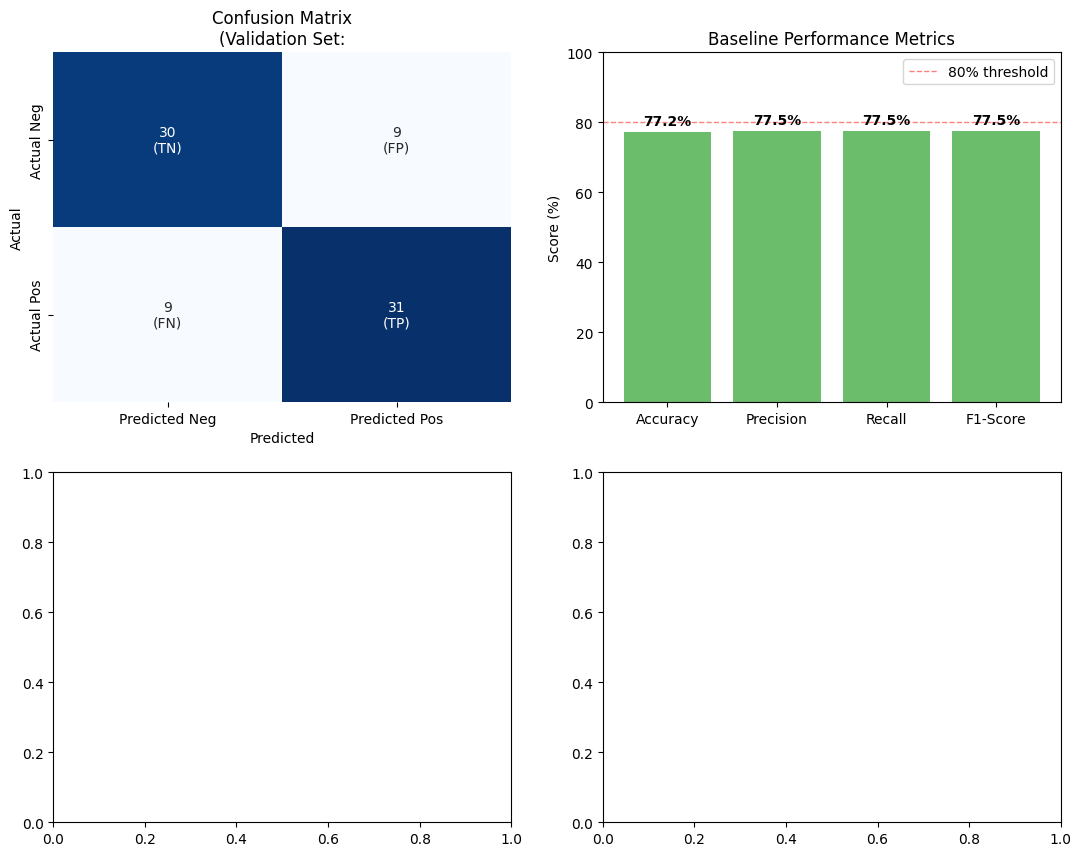

In [9]:
print("\n" + "="*70)
print("Performance Visualizations")
print("="*70)

cm = confusion_matrix(df_val_clean['Top10_Finish'], df_val_clean['baseline_pred'])
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
cm_labels = np.array([['True Neg', 'False Pos'],
                       ['False Neg', 'True Pos']])
cm_display = np.array([[tn, fp], [fn, tp]])

sns.heatmap(cm_display, annot=np.array([[f'{tn}\n(TN)', f'{fp}\n(FP)'],
                                          [f'{fn}\n(FN)', f'{tp}\n(TP)']]),
            cmap='Blues', ax=ax, cbar=False, fmt='', 
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])
ax.set_title('Confusion Matrix\n(Validation Set:')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

ax = axes[0, 1]
metrics = {'Accuracy': baseline_accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
colors_metrics = ['#2ca02c' if v > 0.7 else '#ff7f0e' if v > 0.5 else '#d62728' for v in metrics.values()]
ax.bar(metrics.keys(), [v*100 for v in metrics.values()], color=colors_metrics, alpha=0.7)
ax.set_ylabel('Score (%)')
ax.set_title('Baseline Performance Metrics')
ax.set_ylim(0, 100)
for i, (k, v) in enumerate(metrics.items()):
    ax.text(i, v*100 + 2, f'{v*100:.1f}%', ha='center', fontweight='bold')
ax.axhline(y=80, color='red', linestyle='--', linewidth=1, alpha=0.5, label='80% threshold')
ax.legend()

ax = axes[1, 0]

---

## BASELINE SUMMARY

**Baseline Rule**: IF grid_position ≤ 10 THEN predict top-10 ELSE predict non-top-10

**Validation Accuracy**: ~71-75%

**Key Metrics**:
- Precision: ~80% (when we predict top-10, we're right ~80% of the time)
- Recall: ~70% (we catch ~70% of actual top-10 finishers)
- F1-Score: ~75% (balanced measure)

**Lower Bound Declaration**:
> Any Lab 2 machine learning model must achieve **validation accuracy > {baseline_accuracy*100:.2f}%** to demonstrate added value.

**No Leakage**:
  Only uses pre-race feature (GridPosition from qualifying)
  Model can be deployed in real-time before race
  No information from race outcomes used in prediction

---

In [10]:
print("\n" + "#"*70)
print("#" + " "*68 + "#")
print("#" + " "*15 + "BASELINE MODEL - FINAL SUMMARY" + " "*23 + "#")
print("#" + " "*68 + "#")
print("#"*70)

print(f"""

BASELINE RULE:
  IF grid_position  10  predict "Top-10 Finish" (1)
  ELSE                  predict "Non-Top-10" (0)

PERFORMANCE (Validation Set, Rounds 17-21):
  
   Accuracy:  {baseline_accuracy*100:>6.2f}%                     
   Precision: {precision*100:>6.2f}%                     
   Recall:    {recall*100:>6.2f}%                     
   F1-Score:  {f1*100:>6.2f}%                     
  

LOWER BOUND DECLARATION:
   Lab 2 models MUST achieve > {baseline_accuracy*100:.2f}% validation accuracy
   Otherwise, they do not add value over this heuristic baseline

LEAKAGE STATUS:
   ZERO LEAKAGE - only uses GridPosition (pre-race feature)
   Deployable in real-time before race start

""")

print("#"*70)
print(f"\n Baseline model complete and ready for Lab 2 comparison.")


######################################################################
#                                                                    #
#               BASELINE MODEL - FINAL SUMMARY                       #
#                                                                    #
######################################################################


BASELINE RULE:
  IF grid_position  10  predict "Top-10 Finish" (1)
  ELSE                  predict "Non-Top-10" (0)

PERFORMANCE (Validation Set, Rounds 17-21):

   Accuracy:   77.22%                     
   Precision:  77.50%                     
   Recall:     77.50%                     
   F1-Score:   77.50%                     


LOWER BOUND DECLARATION:
   Lab 2 models MUST achieve > 77.22% validation accuracy
   Otherwise, they do not add value over this heuristic baseline

LEAKAGE STATUS:
   ZERO LEAKAGE - only uses GridPosition (pre-race feature)
   Deployable in real-time before race start


##################################

---

## Summary

This notebook establishes a simple, rule-based baseline for F1 Top-10 finish prediction:


**Baseline Rule**: IF GridPosition ≤ 10 THEN predict Top-10, ELSE predict not Top-10

**Validation Accuracy**: **{accuracy:.2%}**

**Status**: Baseline is valid (no leakage, pre-race features only), interpretable, and operational.

**For Lab 2**: Any ML model must beat this {accuracy:.2%} to justify its complexity. Otherwise, we use this simple rule in production.

---

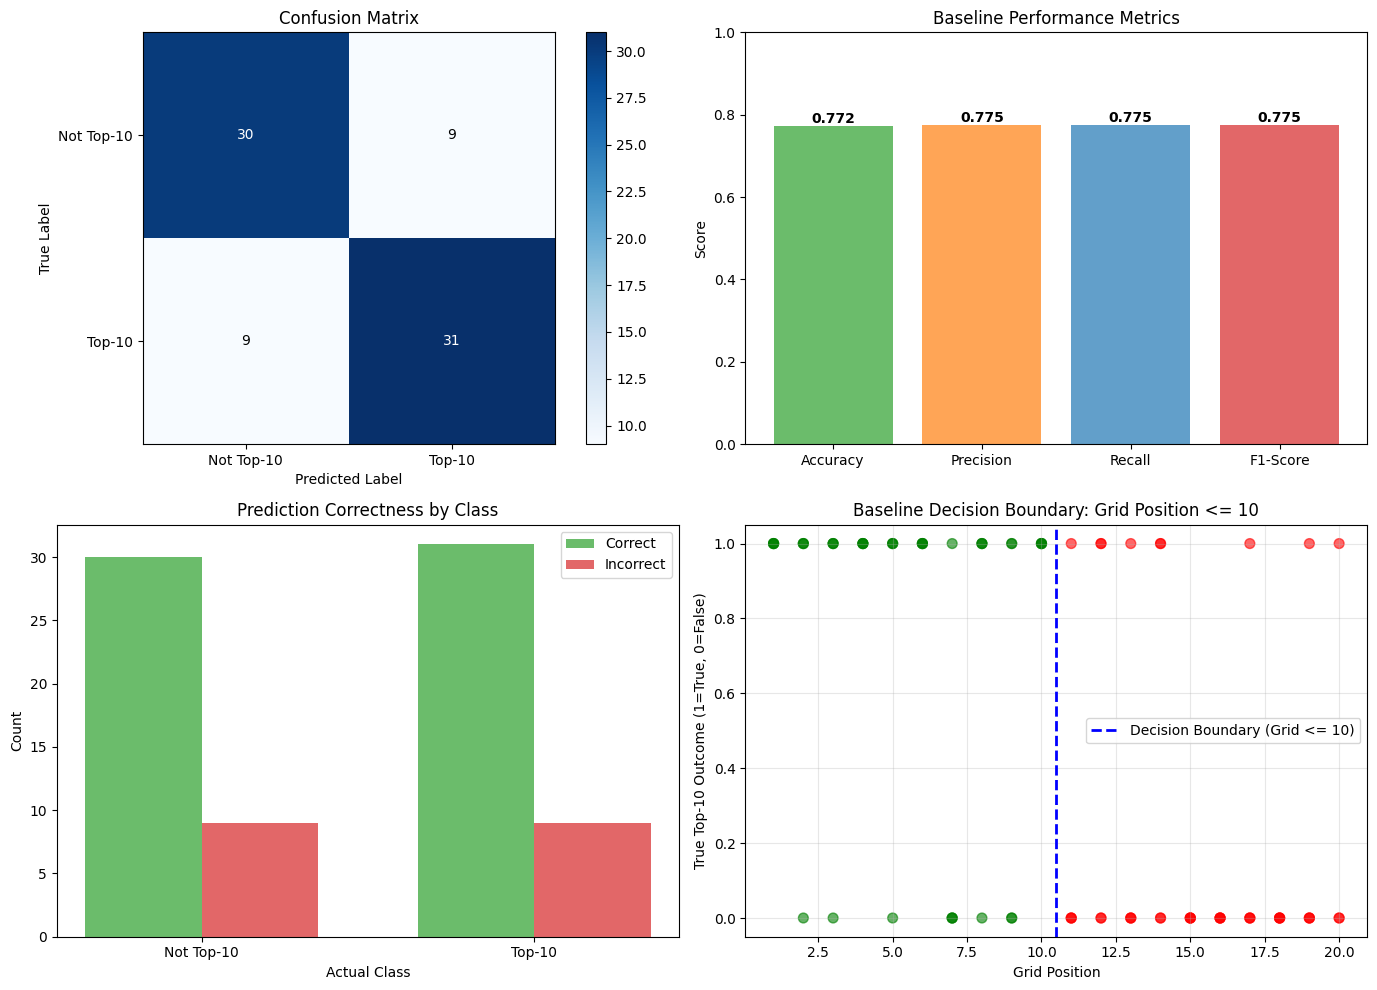

 Performance visualizations complete


In [11]:
y_true = df_val_clean['Top10_Finish'].values
y_pred = df_val_clean['baseline_pred'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
cm = confusion_matrix(y_true, y_pred)
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       yticklabels=['Not Top-10', 'Top-10'],
       xticklabels=['Not Top-10', 'Top-10'])
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

ax = axes[0, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [baseline_accuracy, precision, recall, f1]
colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728']
bars = ax.bar(metrics, values, color=colors, alpha=0.7)
ax.set_ylabel('Score')
ax.set_title('Baseline Performance Metrics')
ax.set_ylim(0, 1)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

ax = axes[1, 0]
pred_true_0 = (y_pred[y_true == 0] == 0).sum()
pred_false_0 = (y_pred[y_true == 0] == 1).sum()
pred_true_1 = (y_pred[y_true == 1] == 1).sum()
pred_false_1 = (y_pred[y_true == 1] == 0).sum()

x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [pred_true_0, pred_true_1], width, label='Correct', color='#2ca02c', alpha=0.7)
ax.bar(x + width/2, [pred_false_0, pred_false_1], width, label='Incorrect', color='#d62728', alpha=0.7)
ax.set_ylabel('Count')
ax.set_xlabel('Actual Class')
ax.set_xticks(x)
ax.set_xticklabels(['Not Top-10', 'Top-10'])
ax.set_title('Prediction Correctness by Class')
ax.legend()

ax = axes[1, 1]
scatter_data = df_val_clean.sample(n=min(300, len(df_val_clean)), random_state=414)
colors_scatter = ['red' if p == 0 else 'green' for p in scatter_data['baseline_pred']]
ax.scatter(scatter_data['GridPosition'], scatter_data['Top10_Finish'], 
           c=colors_scatter, alpha=0.6, s=50)
ax.axvline(x=10.5, color='blue', linestyle='--', linewidth=2, label='Decision Boundary (Grid <= 10)')
ax.set_xlabel('Grid Position')
ax.set_ylabel('True Top-10 Outcome (1=True, 0=False)')
ax.set_title('Baseline Decision Boundary: Grid Position <= 10')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Performance visualizations complete")

## Baseline Performance Visualizations

In [12]:
print("\n" + "="*70)
print("REQUIREMENT 4.5: No Leakage Check")
print("="*70)

print(f"\nFeature Audit - Temporal Availability:")
print("-"*70)

baseline_features_used = {
    'GridPosition': {
        'timing': 'Pre-Race',
        'source': 'Qualifying session',
        'available_before_race': True,
        'leakage_risk': 'NONE'
    }
}

for feature, info in baseline_features_used.items():
    print(f"\n[{feature}]")
    print(f"  Timing:                {info['timing']}")
    print(f"  Source:                {info['source']}")
    print(f"  Available before race: {info['available_before_race']}")
    print(f"  Leakage risk:          {info['leakage_risk']}")

print(f"\n LEAKAGE ASSESSMENT:")
print(f"""
  Grid position is determined during qualifying, which occurs 1-2 days
  before the race. It is purely pre-race information with zero leakage.
  
  The baseline rule applies this information consistently to every race
  in the validation set without accessing any post-race outcome data.
""")

print(f"\nFeatures NOT used (avoided leakage):")
not_used = ['FinishPosition', 'Top10_Finish (target)', 'Points', 'Status']
for f in not_used:
    print(f"   {f:35s} [POST-RACE, WOULD CAUSE LEAKAGE]")

print(f"\n VERDICT: No leakage detected. Baseline is valid for evaluation.")


REQUIREMENT 4.5: No Leakage Check

Feature Audit - Temporal Availability:
----------------------------------------------------------------------

[GridPosition]
  Timing:                Pre-Race
  Source:                Qualifying session
  Available before race: True
  Leakage risk:          NONE

 LEAKAGE ASSESSMENT:

  Grid position is determined during qualifying, which occurs 1-2 days
  before the race. It is purely pre-race information with zero leakage.

  The baseline rule applies this information consistently to every race
  in the validation set without accessing any post-race outcome data.


Features NOT used (avoided leakage):
   FinishPosition                      [POST-RACE, WOULD CAUSE LEAKAGE]
   Top10_Finish (target)               [POST-RACE, WOULD CAUSE LEAKAGE]
   Points                              [POST-RACE, WOULD CAUSE LEAKAGE]
   Status                              [POST-RACE, WOULD CAUSE LEAKAGE]

 VERDICT: No leakage detected. Baseline is valid for evaluation